In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random as rand
#CODE AND DEFINE CUSTOM CUBIC SPLINE

In [2]:
#STEP 1 Define Known Data Points
x= rand.sample(range(0,11),5)
x= np.sort(x)
y= rand.sample(range(0,11),5)
print ("X array: ", x)
print ("Y array: ", y)

X array:  [1 2 3 8 9]
Y array:  [5, 7, 0, 10, 3]


In [3]:
#STEP 2 Calculate Step Sizes
def adding_h (x):
    h=[]
    for i in range (len(x)-1):
        h_x = x[i+1]-x[i]
        h.append(h_x)
    return np.array(h)
h=adding_h(x)
print ("step size is equal to h vector: ", h)

step size is equal to h vector:  [1 1 5 1]


In [4]:
#STEP 3 Set up and Solve Tridiagonal System
#Smoothness Condition
n= len(x)

a= np.zeros(n)
b= np.zeros(n)
c= np.zeros(n)
d= np.zeros(n)

#natural boundaries: CHATTED THIS
b[0]=1
d[0]=0

b[n-1]=1
d[n-1]=0

for i in range(1,n-1):
    a[i-1]= h[i-1]
    b[i]= 2*(h[i-1]+h[i])
    c[i]= h[i]
    d[i]= 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1]))
    
#Thomas Algorithm:
import numpy as np
def thomas_algorithm(a, b, c, d):
    n = len(b)
# Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
# Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

M= thomas_algorithm(a.copy(),b.copy(),c.copy(),d.copy())
print("M:", M)

M: [  0.         -15.82758621   9.31034483  -8.37931034   0.        ]


In [5]:
#Step 4 Eval Spline
def evaluate_spline(x, y, M, xeval):
    h = np.diff(x)
    
    # Step 1: find correct interval
    for i in range(len(x) - 1):
        if x[i] <= xeval <= x[i+1]:
            break
    
    # Step 2: compute spline using formula
    hi = h[i]
    
    term1 = M[i] * (x[i+1] - xeval)**3 / (6 * hi)
    term2 = M[i+1] * (xeval - x[i])**3 / (6 * hi)
    
    term3 = (y[i]/hi - M[i]*hi/6) * (x[i+1] - xeval)
    term4 = (y[i+1]/hi - M[i+1]*hi/6) * (xeval - x[i])
    
    return term1 + term2 + term3 + term4

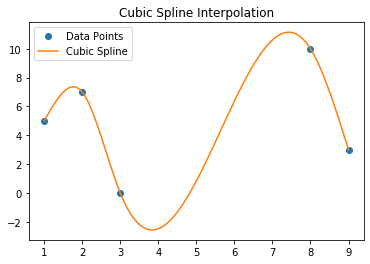

In [6]:
#PLOT
xevals = np.linspace(min(x), max(x), 100)
yevals = [evaluate_spline(x, y, M, xv) for xv in xevals]
plt.plot(x, y, 'o', label='Data Points')
plt.plot(xevals, yevals, label='Cubic Spline')
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.show()